Pandas的DataFrame和Series，在matplotlib基础上封装了一个简易的绘图函数, 使得我们在数据处理过程中方便可视化查看结果。

- 好处: 方便快捷的可视化的方式洞察数据， 覆盖常用图标类型
- 不足: 不如Matplotlib灵活，仅仅看下分布情况，基本是足满足日常使用

Pandas 对 Matplotlib 绘图软件包的基础上单独封装了一个plot()接口，通过调用该接口可以实现常用的绘图操作

Pandas 之所以能够实现了数据可视化，主要利用了 Matplotlib 库的 plot() 方法，它对 plot() 方法做了简单的封装，因此您可以直接调用该接口。

下面看一组简单的示例： 

In [7]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
# 设置中文:
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
# 中文负号
plt.rcParams['axes.unicode_minus'] = False

In [2]:
data = np.random.randn(8,4)
data

array([[-0.95581908, -0.22326719,  0.57651393, -1.94969566],
       [-0.12257666, -0.44316125, -1.02750968, -0.51579996],
       [ 0.40448825, -1.83907228,  1.3905886 ,  0.48219926],
       [ 0.88693524, -0.23111229, -0.01153136, -1.61161717],
       [ 1.13755227,  0.97550659, -0.3500129 ,  0.8600066 ],
       [ 0.73496412,  0.97178066, -1.69022582, -0.54424653],
       [-2.22590644,  0.10941348,  0.77356135,  0.19771268],
       [ 0.3482948 , -0.88970954, -1.16560597,  0.07242299]])

In [3]:
#创建包含时间序列的数据
df = pd.DataFrame(data,index=pd.date_range('2/1/2020',periods=8), columns=list('ABCD'))
df

,A,B,C,D
2020-02-01,-0.955819,-0.223267,0.576514,-1.949696
2020-02-02,-0.122577,-0.443161,-1.027510,-0.515800
2020-02-03,0.404488,-1.839072,1.390589,0.482199
2020-02-04,0.886935,-0.231112,-0.011531,-1.611617
2020-02-05,1.137552,0.975507,-0.350013,0.860007
2020-02-06,0.734964,0.971781,-1.690226,-0.544247
2020-02-07,-2.225906,0.109413,0.773561,0.197713
2020-02-08,0.348295,-0.889710,-1.165606,0.072423


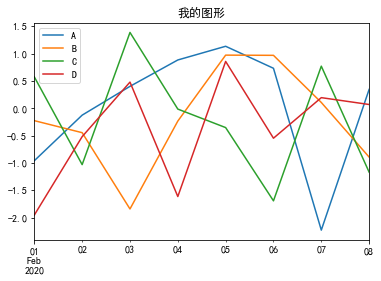

In [12]:
# plot绘制图形, DataFrame数据结构. 存在一个行索引(x轴数据)
# 多少列数据,图形中绘制多少线条
df.plot(title="我的图形")
# 显示图形
plt.show()

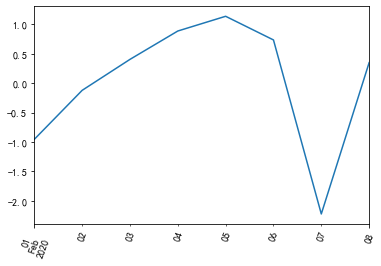

In [17]:
df["A"].plot(rot=70)

(array([737456., 737457., 737458., 737459., 737460., 737461., 737462.,
        737463.]),
 <a list of 8 Text xticklabel objects>)

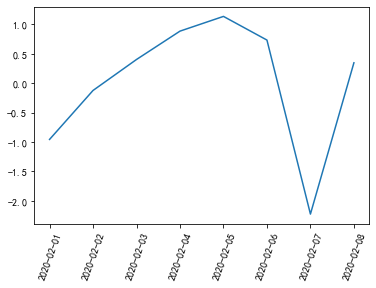

In [16]:
plt.plot(df["A"].index,df["A"])
plt.xticks(rotation=70)

除了使用默认的线条绘图外，您还可以使用其他绘图方式，如下所示：

    柱状图：bar() 或 barh()
    直方图：hist()
    箱状箱：box()
    区域图：area()
    散点图：scatter()


通过关键字参数kind可以把上述方法传递给 plot()。

## 柱状图
创建一个柱状图，如下所示：

In [19]:
df = pd.DataFrame(np.random.rand(8,4),columns=['a','b','c','d'])
df

,a,b,c,d
0,0.038591,0.363555,0.043918,0.484806
1,0.702373,0.429103,0.662018,0.981301
2,0.507210,0.628862,0.212398,0.328872
3,0.140513,0.867745,0.234422,0.555711
4,0.257960,0.973661,0.819206,0.642865
5,0.054192,0.937694,0.908200,0.836345
6,0.759992,0.608659,0.595804,0.841474
7,0.498028,0.621414,0.183642,0.545249


In [31]:
#或使用df.plot(kind="bar")
#df.plot.bar()
df.plot(kind="bar")

AttributeError: 'DataFrame' object has no attribute 'bar'

通过设置参数stacked=True可以生成柱状堆叠图，示例如下：

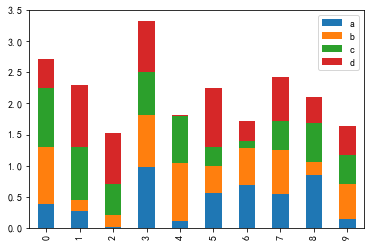

In [23]:
df.plot(kind="bar",stacked=True)
#或者使用df.plot.bar(stacked="True")

如果要绘制水平柱状图，您可以使用以下方法：

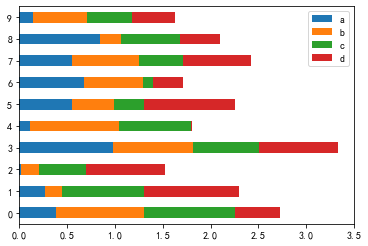

In [24]:
#df = pd.DataFrame(np.random.rand(10,4),columns=['a','b','c','d'])
#print(df)
df.plot.barh(stacked=True)

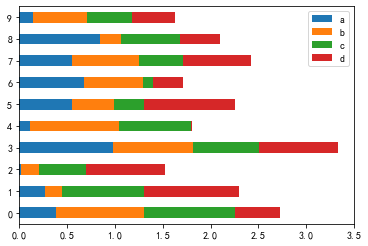

In [25]:
df.plot(kind="barh", stacked=True)

## 直方图
 plot.hist() 可以实现绘制直方图，并且它还可以指定 bins（构成直方图的箱数）。

In [26]:
df = pd.DataFrame({'A':np.random.randn(100)+2, 'B':np.random.randn(100), 'C': np.random.randn(100)-2}, columns=['A', 'B', 'C'])
df

,A,B,C
0,2.192615,-0.436740,-1.397474
1,2.598197,-2.508679,-2.349259
2,0.129868,-0.643098,-2.014222
3,1.634850,1.499613,-0.974421
4,2.721269,0.466643,-0.847714
...,...,...,...
95,3.286402,1.113374,-1.335460
96,3.286364,-1.265668,-2.963370
97,3.477531,-0.765735,-2.686762
98,2.736288,1.153528,-4.636418


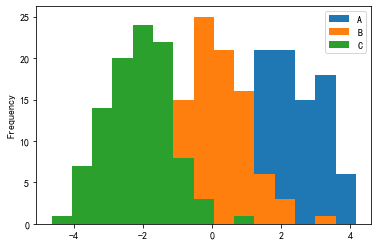

In [27]:
#指定箱数为15
df.plot.hist(bins=15)

给每一列数据都绘制一个直方图，需要使以下方法

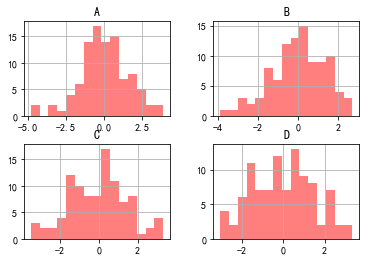

In [28]:
from matplotlib import pyplot as plt
df = pd.DataFrame({'A':np.random.randn(100)+2,'B':np.random.randn(100),'C':
np.random.randn(100)-2,'D':np.random.randn(100)+3},columns=['A', 'B', 'C','D'])

#使用diff绘制
df.diff().hist(color="r",alpha=0.5,bins=15)
plt.show()

## 箱型图
通过调用 Series.box.plot() 、DataFrame.box.plot() 或者 DataFrame.boxplot() 方法来绘制箱型图，它将每一列数据的分布情况，以可视化的图像展现出来。 

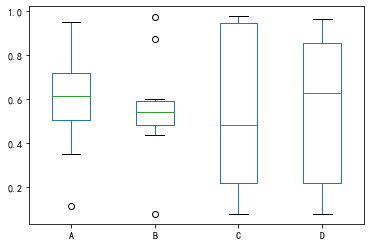

In [32]:
df = pd.DataFrame(np.random.rand(10, 4), columns=['A', 'B', 'C', 'D'])
df.plot.box()

## 区域图
您可以使用 Series.plot.area() 或 DataFrame.plot.area() 方法来绘制区域图。

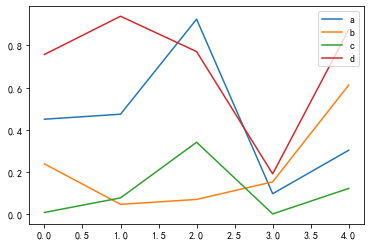

In [35]:
df = pd.DataFrame(np.random.rand(5, 4), columns=['a', 'b', 'c', 'd'])
df.plot()
#df.plot.area()

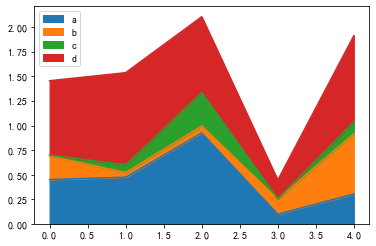

In [36]:
df.plot.area()

## 散点图
使用 DataFrame.plot.scatter() 方法来绘制散点图，如下所示： 

           a         b         c         d
0   0.837541  0.081426  0.066455  0.635873
1   0.108635  0.270461  0.093794  0.669127
2   0.917106  0.258013  0.525292  0.472016
3   0.821140  0.618018  0.489726  0.459237
4   0.612659  0.760135  0.574323  0.079131
5   0.882499  0.127358  0.076842  0.547341
6   0.482573  0.367087  0.249419  0.078445
7   0.462865  0.233761  0.229724  0.318050
8   0.447621  0.527298  0.505243  0.776544
9   0.285926  0.679094  0.659492  0.634078
10  0.973203  0.322570  0.747146  0.712025
11  0.266998  0.284955  0.033136  0.897455
12  0.836701  0.685095  0.184601  0.539120
13  0.284894  0.790805  0.955768  0.339643
14  0.605587  0.198911  0.861091  0.718924
15  0.203403  0.400651  0.228260  0.678833
16  0.857331  0.101184  0.014788  0.776628
17  0.818306  0.014192  0.996573  0.707441
18  0.701615  0.217776  0.436047  0.513484
19  0.622950  0.104925  0.426548  0.932383
20  0.359421  0.004785  0.625251  0.456017
21  0.817161  0.192477  0.216112  0.917107
22  0.12085

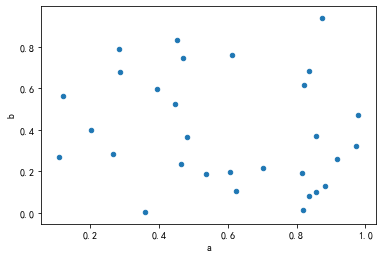

In [39]:
data = np.random.rand(30, 4)
df = pd.DataFrame(data, columns=['a', 'b', 'c', 'd'])
print(df)
df.plot.scatter(x="a",y='b')

## 饼状图
饼状图可以通过 DataFrame.plot.pie() 方法来绘制。示例如下：

In [41]:
df = pd.DataFrame(3 * np.random.rand(4), index=['go', 'java', 'c++', 'c'], columns=['L'])
df

,L
go,2.075609
java,2.494046
c++,2.130465
c,1.137792


array([<matplotlib.axes._subplots.AxesSubplot object at 0x0000023FC7E03E08>],
      dtype=object)

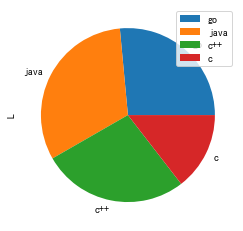

In [44]:
# 饼状图需要添加subplots
df.plot.pie(subplots=True)

## DataFrame.plot详解:



`DataFrame.plot(x=None, y=None, kind='line', ax=None, subplots=False, 
                sharex=None, sharey=False, layout=None,figsize=None, 
                use_index=True, title=None, grid=None, legend=True, 
                style=None, logx=False, logy=False, loglog=False, 
                xticks=None, yticks=None, xlim=None, ylim=None, rot=None,
                xerr=None,secondary_y=False, sort_columns=False, **kwds)`
- `x` : label or position, default None#指数据框列的标签或位置参数

- `y` : label or position, default None

- `kind` : str
    ‘line’ : line plot (default)#折线图
    ‘bar’ : vertical bar plot#条形图
    ‘barh’ : horizontal bar plot#横向条形图
    ‘hist’ : histogram#柱状图
    ‘box’ : boxplot#箱线图
    ‘kde’ : Kernel Density Estimation plot#Kernel 的密度估计图，主要对柱状图添加Kernel 概率密度线
    ‘area’ : area plot#区域图
    ‘pie’ : pie plot#饼图
    ‘scatter’ : scatter plot#散点图  需要传入columns方向的索引

- `ax` : matplotlib axes object, default None#**子图(axes, 也可以理解成坐标轴) 要在其上进行绘制的matplotlib subplot对象。如果没有设置，则使用当前matplotlib subplot**其中，变量和函数通过改变figure和axes中的元素（例如：title,label,点和线等等）一起描述figure和axes，也就是在画布上绘图。
- subplots : boolean, default False#判断图片中是否有子图
- `sharex` : boolean, default True if ax is None else False#如果有子图，子图共x轴刻度，标签
- `sharey` : boolean, default False#如果有子图，子图共y轴刻度，标签
- `layout` : tuple (optional)#子图的行列布局 (rows, columns) for the layout of subplots
- `figsize` : a tuple (width, height) in inches#图片尺寸大小
- `use_index` : boolean, default True#默认用索引做x轴
- `title` : string#图片的标题用字符串

- `grid` : boolean, default None (matlab style default)#图片是否有网格
- `legend` : False/True/’reverse’#子图的图例，添加一个subplot图例(默认为True)
- `style` : list or dict#对每列折线图设置线的类型
- `logx` : boolean, default False#设置x轴刻度是否取对数
- `xticks` : sequence#设置x轴刻度值，序列形式（比如列表）
- `yticks` : sequence#设置y轴刻度，序列形式（比如列表）
- `xlim` : 2-tuple/list#设置坐标轴的范围，列表或元组形式
- `ylim` : 2-tuple/list
- `rot` : int, default None#设置轴标签（轴刻度）的显示旋转度数

- `fontsize` : int, default None#设置轴刻度的字体大小
- `colormap` : str or matplotlib colormap object, default None#设置图的区域颜色
- `position` : float   
- `table` : boolean, Series or DataFrame, default False  #如果为正，则选择DataFrame类型的数据并且转换匹配matplotlib的布局。
- `stacked` : boolean, default False in line and # 为True创建叠状图
- `sort_columns` : boolean, default False  # 以字母表顺序绘制各列，默认使用前列顺序